
#**Instruções antes de rodar o código:**

-Baixar o arquivo chamado de Dadoslimpos em formato .csv  O arquivo esta no
[link](https://docs.google.com/spreadsheets/d/1LrzWAE32hGWRYUetYDOkVxKjpiSf3D5NjluW-80Dmwo/edit?usp=sharing)


-Mudar o nome conforme o código abaixo (ArtigoDadosLimpos.csv)


# Memorial de Cálculo – Artigo

## Segregação Socioespacial, Saneamento Básico e Racismo Ambiental em Niterói (RJ)

Este notebook documenta todo o processamento estatístico realizado para geração dos gráficos apresentados no artigo **"Segregação Socioespacial, Saneamento Básico e Racismo Ambiental em Niterói-RJ"**. Seu objetivo é funcionar como um **memorial de cálculo**, permitindo que todas as etapas da análise sejam reproduzidas de forma transparente.

Os procedimentos implementados incluem:

- importação e tratamento dos dados do Censo Demográfico de 2010 (IBGE);
- cálculo dos indicadores de abastecimento de água, coleta de resíduos sólidos e esgotamento sanitário por setor censitário;
- construção do **Índice E.L.A. (Esgotamento, Lixo e Água)**, obtido pela média aritmética simples dos três indicadores de saneamento;
- classificação dos setores censitários segundo faixas de renda e proporção de população negra;
- geração dos gráficos exploratórios (boxplots e dispersões);
- regressão linear múltipla (OLS) com padronização das variáveis independentes (StandardScaler);
- regressão quantílica para avaliação do comportamento dos coeficientes ao longo da distribuição do Índice E.L.A.

Todas as análises foram desenvolvidas em **Python**, utilizando principalmente as bibliotecas:

- Pandas
- NumPy
- Matplotlib
- Plotly
- Statsmodels
- Scikit-Learn

Este notebook não substitui a descrição metodológica apresentada no artigo, mas documenta detalhadamente sua implementação computacional, permitindo a reprodução integral dos resultados e figuras.

# Leitura e preparação de dados

In [2]:
import pandas as pd

# Substitua com o nome exato, se for diferente

df = pd.read_csv('ArtigoDadosLimpos.csv')

# Verifique as colunas
print(df.columns)

# Visualize as primeiras linhas
df.head()
df.columns = df.columns.str.strip()


Index(['Cod_setor ', 'CIDADE', 'BAIRRO', 'POP V0002', 'DOM V001', 'ÁGUA V012',
       'ESG. V017', 'LIXO V035', 'Residentes ', 'branca ', 'preta', 'amarela',
       'parda', 'INDÍGENA ', 'Renda dom.', 'Sem renda', 'ÁGUA V012 %',
       'ESG. V017 %', 'LIXO V035 %', 'soma', 'ind.mariana'],
      dtype='object')


In [3]:
cols_numericas = [
    'POP V0002', 'DOM V001', 'ÁGUA V012', 'ESG. V017', 'LIXO V035',
    'Residentes', 'branca', 'preta', 'amarela', 'parda', 'INDÍGENA',
    'Renda dom.', 'Sem renda'
]

df[cols_numericas] = df[cols_numericas].apply(pd.to_numeric, errors="coerce")

In [4]:
df.describe()

,Cod_setor,POP V0002,DOM V001,ÁGUA V012,ESG. V017,LIXO V035,Residentes,branca,preta,amarela,parda,INDÍGENA,Renda dom.,Sem renda
count,8.920000e+02,885.000000,892.000000,878.000000,878.000000,878.000000,892.000000,891.000000,891.000000,891.000000,891.000000,891.000000,8.920000e+02,892.000000
mean,3.303302e+14,547.929944,192.364350,187.404328,167.552392,190.449886,546.594170,347.001122,51.484848,3.038159,143.690236,0.734007,8.883732e+05,7.781390
std,2.602036e+02,272.325912,93.193417,89.101811,92.098598,90.465811,274.091113,207.312647,60.723897,4.442226,127.472573,2.057040,8.119388e+05,10.346433
min,3.303302e+14,2.000000,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,3.303302e+14,366.000000,131.750000,129.250000,102.000000,132.000000,364.000000,187.000000,12.000000,0.000000,55.500000,0.000000,2.704240e+05,2.000000
50%,3.303302e+14,527.000000,194.000000,188.500000,170.000000,192.000000,527.000000,335.000000,29.000000,2.000000,101.000000,0.000000,6.377600e+05,4.000000
75%,3.303302e+14,713.000000,253.000000,247.250000,233.000000,251.000000,711.500000,483.000000,68.000000,4.000000,191.000000,1.000000,1.285963e+06,9.000000
max,3.303302e+14,1964.000000,634.000000,580.000000,550.000000,591.000000,1970.000000,1289.000000,436.000000,43.000000,974.000000,40.000000,4.987177e+06,123.000000


In [5]:
df = df.dropna(axis=0)

In [6]:
df.describe()

,Cod_setor,POP V0002,DOM V001,ÁGUA V012,ESG. V017,LIXO V035,Residentes,branca,preta,amarela,parda,INDÍGENA,Renda dom.,Sem renda
count,8.710000e+02,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,871.000000,8.710000e+02,871.000000
mean,3.303302e+14,556.134328,195.203215,188.910448,168.898967,191.980482,557.554535,354.471871,52.329506,3.107922,146.393800,0.750861,9.097921e+05,7.969001
std,2.589996e+02,266.466558,89.776139,87.853071,91.228846,89.194896,267.025784,203.504410,60.951275,4.468775,127.298545,2.077503,8.097211e+05,10.398837
min,3.303302e+14,12.000000,7.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,3.303302e+14,374.500000,137.000000,132.000000,103.000000,133.000000,376.500000,199.000000,13.000000,0.000000,57.000000,0.000000,2.922505e+05,2.000000
50%,3.303302e+14,535.000000,196.000000,189.000000,171.000000,193.000000,541.000000,343.000000,29.000000,2.000000,104.000000,0.000000,6.559970e+05,5.000000
75%,3.303302e+14,716.500000,255.000000,248.500000,234.000000,251.500000,720.500000,487.500000,68.000000,4.000000,196.000000,1.000000,1.296500e+06,9.500000
max,3.303302e+14,1964.000000,594.000000,580.000000,550.000000,591.000000,1970.000000,1289.000000,436.000000,43.000000,974.000000,40.000000,4.987177e+06,123.000000


##Criar indices
Optamos por criar indices com valores entre 0 e 100, para representar melhor a porcentagem nos gráficos

In [7]:
df["plixo"] = df["LIXO V035"] / df["DOM V001"]
df["plixo"] = df["plixo"] *100
df["pesg"] = df["ESG. V017"] / df["DOM V001"]
df["pesg"] = df["pesg"] *100
df["pagua"] = df["ÁGUA V012"] / df["DOM V001"]
df["pagua"] = df["pagua"] *100


df['ELA'] = (df["plixo"] + df["pesg"] +df["pagua"]  )  /3


df['pbranca'] = df["branca"] / df["POP V0002"]
df['pbranca'] = df['pbranca'] *100

df['ppreta'] = df["preta"] / df["POP V0002"]
df['ppreta'] = df['ppreta'] *100


df['pparda'] = df['parda'] / df['POP V0002']
df['pparda'] = df['pparda'] *100


df['pnegra'] = (df['preta']+df['parda']) / df['POP V0002']
df['pnegra'] = df['pnegra']*100

df['renda'] = df['Renda dom.'] / df["DOM V001"]

df['pbranca'] = df['pbranca'].clip(upper=100) #Garante não ter valores maiores do que 1
# Número de linhas antes
antes = len(df)

# Filtrar removendo ELA == 0
df = df[df['ELA'] != 0]

# Número de linhas depois
depois = len(df)

# Quantas foram eliminadas
eliminadas = antes - depois

print(f"Linhas eliminadas: {eliminadas}")


Linhas eliminadas: 2


In [8]:
df.describe()

,Cod_setor,POP V0002,DOM V001,ÁGUA V012,ESG. V017,LIXO V035,Residentes,branca,preta,amarela,...,Sem renda,plixo,pesg,pagua,ELA,pbranca,ppreta,pparda,pnegra,renda
count,8.690000e+02,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,...,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000,869.000000
mean,3.303302e+14,556.929804,195.501726,189.345224,169.287687,192.422325,558.353280,355.287687,52.449942,3.115075,...,7.987342,98.221473,85.420239,96.663899,93.435204,63.622906,9.602190,26.331280,35.933470,4388.803749
std,2.585423e+02,266.231758,89.656611,87.484445,90.972511,88.819719,266.788505,203.025333,60.969614,4.471427,...,10.403765,5.773641,24.248053,7.799057,10.148871,22.175046,9.371501,15.146414,22.047689,3048.581957
min,3.303302e+14,12.000000,7.000000,4.000000,0.000000,7.000000,12.000000,3.000000,0.000000,0.000000,...,0.000000,27.222222,0.000000,14.864865,26.126126,4.347826,0.000000,0.000000,2.830189,722.008475
25%,3.303302e+14,376.000000,137.000000,132.000000,103.000000,133.000000,378.000000,200.000000,13.000000,0.000000,...,2.000000,99.342105,83.408072,96.460177,91.304348,45.914397,2.553191,13.238289,16.013072,1794.386364
50%,3.303302e+14,539.000000,196.000000,189.000000,171.000000,193.000000,541.000000,343.000000,29.000000,2.000000,...,5.000000,100.000000,97.652582,99.447514,98.569385,68.352060,6.654344,24.008811,30.852713,3608.653543
75%,3.303302e+14,717.000000,255.000000,249.000000,234.000000,252.000000,721.000000,488.000000,68.000000,4.000000,...,10.000000,100.000000,100.000000,100.000000,99.856938,83.574879,14.115308,38.336520,53.623188,6483.539749
max,3.303302e+14,1964.000000,594.000000,580.000000,550.000000,591.000000,1970.000000,1289.000000,436.000000,43.000000,...,123.000000,100.000000,100.000000,100.000000,100.000000,100.000000,72.463768,78.873239,95.652174,19107.957854


## Grafico de saneamento básico por faixa de população negra

In [9]:
import pandas as pd
import plotly.express as px


# Primeiro calculamos os limites numéricos exatos dos 4 grupos (quantis)
limites = df['pnegra'].quantile([0, 0.20, 0.40, 0.60, 0.8, 1.0]).values

# Criamos os labels dinamicamente mostrando as porcentagens reais de cada grupo
labels_percentuais = [
    f"{limites[0]:.1f}% a {limites[1]:.1f}%",
    f"{limites[1]:.1f}% a {limites[2]:.1f}%",
    f"{limites[2]:.1f}% a {limites[3]:.1f}%",
    f"{limites[3]:.1f}% a {limites[4]:.1f}%",
    f"{limites[4]:.1f}% a {limites[5]:.1f}%"
]

# Aplicamos o qcut usando os labels calculados
df['faixa_pnegra'] = pd.qcut(
    df['pnegra'],
    q=5,
    labels=labels_percentuais
)

# 2. Reestruturando o DataFrame para o formato longo (Mantido seu código original)
df_longo = df.melt(
    id_vars=['faixa_pnegra'],
    value_vars=['pesg', 'plixo', 'pagua'],
    var_name='Serviço',
    value_name='Porcentagem'
)

# Mapeando nomes mais bonitos para a legenda interna do DataFrame
nomes_servicos = {
    "pesg": "Coleta de Esgoto",
    "plixo": "Coleta de Lixo",
    "pagua": "Acesso à Água"
}
df_longo['Serviço'] = df_longo['Serviço'].map(nomes_servicos)

# 3. Criando o Boxplot Agrupado (Mantido seu esquema de cores)
fig = px.box(
    df_longo,
    x="faixa_pnegra",
    y="Porcentagem",
    color="Serviço",
    title="Saneamento Básico por Faixa Equivalente de População Negra em Niterói",
    labels={
        "faixa_pnegra": "Intervalos da População Negra (Grupos com tamanhos iguais)",
        "Porcentagem": "Acesso / Coleta (%)"
    },
    color_discrete_sequence=["#238B45", "#d94801", "#2171b5"]
)

# 4. Estilo minimalista
fig.update_layout(
    width=950,
    height=550,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=16),
    title=dict(font=dict(size=20)),

    legend_title_text="Serviços",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25, xanchor="left", x=0)
)

# Grelha suave horizontal
fig.update_yaxes(showgrid=True, gridwidth=0.6, gridcolor="#ECECEC", zeroline=False)
fig.update_xaxes(showgrid=False)
fig.update_layout(font=dict(color="black"))

fig.show()

#BoxPlots ELA vs Renda e Ela vs %Negros

## Verificar dados
### Aqui é verificado se renda e %Negros é distribuição normal
Isso permitirá saber que tipo de análise de correlação estatística
Se os dados não são normais, useramos "Spearman"

In [10]:
from scipy import stats

def verificar_normalidade(coluna, nome_variavel):
    stat, p = stats.shapiro(df[coluna])

    print(f"--- Análise: {nome_variavel} ---")
    print(f"Estatística: {stat:.3f}")
    print(f"p-valor: {p:.3f}")

    # Critério de decisão (Nível de significância de 5%)
    if p > 0.05:
        print(f"Conclusão: A variável '{nome_variavel}' segue uma Distribuição Normal.")
    else:
        print(f"Conclusão: A variável '{nome_variavel}' NÃO segue uma Distribuição Normal.")
    print("-" * 30)

# Executando para as duas colunas
verificar_normalidade('pnegra', 'Raça (pnegra)')
verificar_normalidade('renda', 'Renda')

--- Análise: Raça (pnegra) ---
Estatística: 0.937
p-valor: 0.000
Conclusão: A variável 'Raça (pnegra)' NÃO segue uma Distribuição Normal.
------------------------------
--- Análise: Renda ---
Estatística: 0.899
p-valor: 0.000
Conclusão: A variável 'Renda' NÃO segue uma Distribuição Normal.
------------------------------


## Boxplot Raça
Verificar a opção de apresentar os boxplots, por faixas fixas ou por quantis

In [11]:
# --- CONFIGURAÇÃO DA ANÁLISE ---
# Altere para 1 para usar Quantis (mesmo número de bairros por grupo)
# Altere para 0 para usar Faixas Fixas (0-20%, 20-40%, etc.)
DividirEmQuatis = 1

if DividirEmQuatis == 1:
    ### OPÇÃO A: DIVISÃO POR QUANTIS (GRUPOS COM NÚMERO IGUAL DE ELEMENTOS)
    # Esta opção ignora os "números redondos" e foca em colocar a mesma quantidade
    # de dados em cada grupo. É ideal para comparar os 20% mais pobres contra os 20% mais ricos.

    # 1. Calculamos os limites que dividem a base em 5 partes iguais (quintis)
    quantis = df["pnegra"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).unique()

    # 2. Criamos etiquetas que mostram os valores exatos de onde cada grupo começa e termina
    # Exemplo: em vez de "0-20%", pode aparecer "0.5% - 12.3%" (limite real dos dados)
    labels = [f"{quantis[i]:.1f}% - {quantis[i+1]:.1f}%" for i in range(len(quantis)-1)]

    # 3. Classificamos cada linha do arquivo dentro desses grupos calculados
    df["faixa_pnegra"] = pd.cut(df["pnegra"], bins=quantis, labels=labels, include_lowest=True)

    print("Resultado: Divisão por Quantis (Grupos com tamanhos iguais)")
    print(df["faixa_pnegra"].value_counts().sort_index())

else:
    ### OPÇÃO B: DIVISÃO POR PROPORÇÕES FIXAS (INTERVALOS DE 20 EM 20)
    # Esta opção foca em "números redondos" (0-20%, 20-40%...).
    # É mais fácil de ler, mas os grupos podem ficar desequilibrados (um grupo com muitos bairros e outro quase vazio).

    # 1. Definimos os cortes fixos de 20 em 20 unidades
    bins = [0, 20, 40, 60, 80, 100]
    nomes_base = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

    # 2. Contamos quantos elementos caem em cada "caixa" para informar no relatório
    temp_series = pd.cut(df["pnegra"], bins=bins, labels=nomes_base, include_lowest=True)
    contagem = temp_series.value_counts().sort_index()

    # 3. Criamos etiquetas que mostram o nome da faixa e o total de itens (n) nela
    # Isso ajuda o aluno a ver se existe algum grupo "vazio" ou muito pequeno
    novos_labels = [f"{nome} (n={contagem[nome]})" for nome in nomes_base]

    # 4. Aplicamos a classificação definitiva
    df["faixa_pnegra"] = pd.cut(df["pnegra"], bins=bins, labels=novos_labels, include_lowest=True)

    print("Resultado: Divisão por Faixas Fixas (Intervalos de 20%)")
    print(df["faixa_pnegra"].value_counts().sort_index())



Resultado: Divisão por Quantis (Grupos com tamanhos iguais)
faixa_pnegra
2.8% - 14.1%     174
14.1% - 26.1%    174
26.1% - 39.1%    173
39.1% - 59.3%    174
59.3% - 95.7%    174
Name: count, dtype: int64


In [12]:
import plotly.express as px

fig = px.box(
    df,
    x="faixa_pnegra",
    y="ELA",
    title="ELA por faixa de população negra",
    labels={
          "faixa_pnegra": "População negra setor censitario (%) ",
        "ELA": "Índice E.L.A.",
        "tx_nome": "Comunidade"
    },
    color_discrete_sequence=["#8856a7"]
)
# Fundo branco + customização detalhada de fontes e tamanhos
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",

    # 1. Tamanho do Título Principal
    title=dict(
        font=dict(size=22)  # Aumentado para 22 (padrão costuma ser 18)
    ),

    # 2. Tamanho dos Títulos dos Eixos (Labels principais)
    xaxis_title=dict(font=dict(size=20)),
    yaxis_title=dict(font=dict(size=20)),

    # 3. Tamanho dos valores dos eixos (as categorias/números da escala)
    xaxis=dict(tickfont=dict(size=16)),
    yaxis=dict(tickfont=dict(size=16)),

    # 4. Tamanho do texto da Legenda (caso seu gráfico use)
    legend=dict(
        font=dict(size=14),
        title=dict(font=dict(size=15))
    )
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)
fig.update_layout(
    font=dict(color="black")
)

fig.show()

## Boxplot Renda

In [13]:
# --- CONFIGURAÇÃO DA ANÁLISE DE RENDA ---
# Altere para 1 para usar Quantis (mesmo número de bairros por grupo)
# Altere para 0 para usar Faixas Fixas (Ex: de 1000 em 1000 reais)
DividirRendaPorQuantis = 1

if DividirRendaPorQuantis == 1:
    ### OPÇÃO A: DIVISÃO POR QUANTIS (ESTATISTICAMENTE MAIS ROBUSTO)
    # Divide a base em 5 grupos com a mesma quantidade de setores.
    # É a melhor forma de separar os "20% mais pobres" dos "20% mais ricos".

    # 1. Calculamos os limites reais (Ex: o grupo "Muito Rica" pode começar em R$ 5.000 ou R$ 50.000)
    quantis_renda = df["renda"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).unique()

    dolar = "\u0024"
    # 2. Criamos as etiquetas com os valores em Reais para o aluno ver onde cada classe começa
    labels_renda = [f"RS{quantis_renda[i]:.0f} - R${quantis_renda[i+1]:.0f}" for i in range(len(quantis_renda)-1)]

    # 3. Criamos a coluna no banco de dados
    df["faixa_renda"] = pd.cut(df["renda"], bins=quantis_renda, labels=labels_renda, include_lowest=True)

    print("Resultado Renda: Grupos com mesmo número de setores (Quantis)")
    print(df["faixa_renda"].value_counts().sort_index())

else:
    ### OPÇÃO B: DIVISÃO POR VALORES FIXOS (MAIS INTUITIVO)
    # Aqui nós definimos "na mão" o que consideramos renda baixa ou alta.
    # O perigo é que em cidades ricas quase todos podem cair na faixa "Alta"
    # e em cidades pobres todos na "Baixa", desequilibrando o gráfico.

    # 1. Definimos faixas sugeridas (Ajuste os valores conforme a realidade do seu dataset)
    # Exemplo: 0-1k, 1k-2k, 2k-5k, 5k-10k, 10k+
    bins_renda = [0, 1500, 3000, 5000, 10000, df["renda"].max()]
    nomes_renda = ["Até 1.5k", "1.5k-3k", "3k-5k", "5k-10k", "Mais de 10k"]

    # 2. Contamos quantos setores caem em cada definição de riqueza
    temp_renda = pd.cut(df["renda"], bins=bins_renda, labels=nomes_renda, include_lowest=True)
    contagem_renda = temp_renda.value_counts().sort_index()

    # 3. Adicionamos o 'n' para o aluno perceber se os grupos estão equilibrados
    labels_fixos = [f"{nome} (n={contagem_renda[nome]})" for nome in nomes_renda]

    df["faixa_renda"] = pd.cut(df["renda"], bins=bins_renda, labels=labels_fixos, include_lowest=True)

    print("Resultado Renda: Faixas de valores fixos (Definição manual)")
    print(df["faixa_renda"].value_counts().sort_index())

Resultado Renda: Grupos com mesmo número de setores (Quantis)
faixa_renda
RS722 - R$1570      174
RS1570 - R$2655     174
RS2655 - R$4401     173
RS4401 - R$7096     174
RS7096 - R$19108    174
Name: count, dtype: int64


In [14]:
import plotly.express as px

fig = px.box(
    df,
    x="faixa_renda",
    y="ELA",
    title="ELA por faixa de população negra",
    labels={
          "faixa_renda": "Faixa de Renda (R$) ",
        "ELA": "Índice E.L.A.",
        "tx_nome": "Comunidade"
    },
    color_discrete_sequence=["#d95f0e"] )
# Fundo branco + grids cinza claro
# Fundo branco + customização detalhada de fontes e tamanhos
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",

    # 1. Tamanho do Título Principal
    title=dict(
        font=dict(size=22)  # Aumentado para 22 (padrão costuma ser 18)
    ),

    # 2. Tamanho dos Títulos dos Eixos (Labels principais)
    xaxis_title=dict(font=dict(size=20)),
    yaxis_title=dict(font=dict(size=20)),

    # 3. Tamanho dos valores dos eixos (as categorias/números da escala)
    xaxis=dict(tickfont=dict(size=16)),
    yaxis=dict(tickfont=dict(size=16)),

    # 4. Tamanho do texto da Legenda (caso seu gráfico use)
    legend=dict(
        font=dict(size=14),
        title=dict(font=dict(size=15))
    )
)


fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)
fig.update_xaxes(autorange="reversed")
fig.update_layout(    font=dict(color="black"))
fig.show()

# Teste estatistico
Raça é mais significativo que renda?

In [15]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 1. PADRONIZAÇÃO (StandardScaler)
# Por que fazer? 'pnegra' é % e 'renda' é em Reais. O scaler coloca ambos na mesma escala
# (Média 0 e Desvio Padrão 1). Assim, o coeficiente (coef) dirá quem tem MAIOR PESO real.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["pnegra", "renda"]])

# 2. DEFINIÇÃO DAS VARIÁVEIS
y = df["ELA"]  # Variável dependente (o que queremos explicar)
X_scaled = sm.add_constant(X_scaled)  # Adiciona a 'constante' (ponto de partida do gráfico)

# 3. CRIAÇÃO DO MODELO OLS (Mínimos Quadrados Ordinários)  ELA = B1*PNEGRA + B2*RENDA + residuo
modelo_pad = sm.OLS(y, X_scaled).fit()

# 4. EXIBIÇÃO DOS RESULTADOS
print(modelo_pad.summary())

##

#1. R-squared: Olhe no topo. Se for 0.209, o modelo explica ~21% do ELA.
#   É o "poder de explicação" do seu trabalho.

#2. Coluna 'coef' (OS PESOS):
#   - x1 (Raça): Se for -5.34, cada aumento no desvio padrão de raça reduz o ELA em 5.34 pts.
#   - x2 (Renda): Compare o valor absoluto com x1 para ver quem "manda" mais.
#   (No seu caso, Raça tem impacto 6x maior que Renda).

#3. Coluna 'P>|t|' (O P-VALOR):
#   - Se for MENOR que 0.05: A variável é "culpada" (tem influência real).
#   - Se for MAIOR que 0.05: A variável é "inocente" (o resultado pode ser obra do acaso).
#   (No seu caso, Renda deu 0.082, ou seja, não tem significância estatística aqui).

#4. Skew/Kurtosis (SAÚDE DOS DADOS):
#   - Skew longe de 0 ou Kurtosis longe de 3 indica que seus dados são "reais e imperfeitos"
#     (não seguem a distribuição normal), o que valida o uso de Spearman feito anteriormente.

                            OLS Regression Results                            
Dep. Variable:                    ELA   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     114.7
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           6.25e-45
Time:                        13:56:48   Log-Likelihood:                -3144.2
No. Observations:                 869   AIC:                             6294.
Df Residuals:                     866   BIC:                             6309.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         93.4352      0.306    304.892      0.0

Coeficientes Padronizados:
População Negra   -5.340205
Renda             -0.903096
dtype: float64


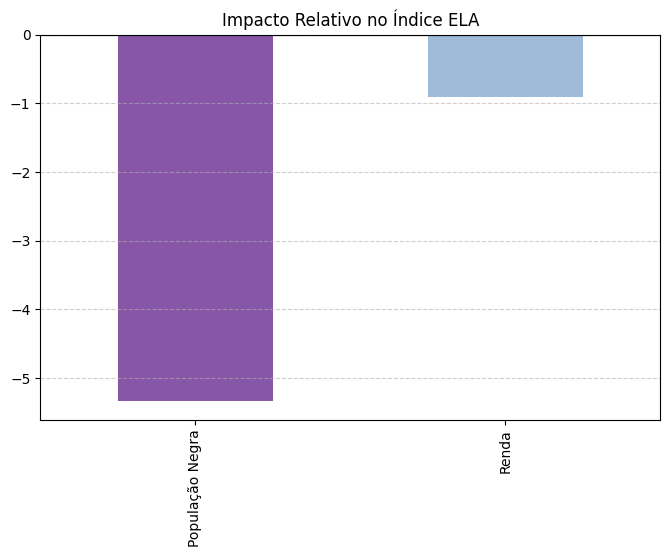

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. CORREÇÃO DO MAPEAMENTO
# O modelo_pad.params contém os números.
# modelo_pad.params[0] é a Constante.
# modelo_pad.params[1] é a primeira variável (Raça).
# modelo_pad.params[2] é a segunda variável (Renda).

# Criamos a Series pegando apenas os valores (.values) para evitar erro de nomes
coef_valores = modelo_pad.params[1:].values
coef = pd.Series(coef_valores, index=["População Negra", "Renda"])

# 2. PRINT PARA CONFERIR
print("Coeficientes Padronizados:")
print(coef)

# 3. GRÁFICO DE BARRAS
plt.figure(figsize=(8, 5))
# Usamos .plot.bar() que é mais direto
coef.plot(kind="bar", color=["#8856a7", "#9ebcda"])

plt.title("Impacto Relativo no Índice ELA", fontsize=12)
plt.axhline(0, color='black', linewidth=0.8) # Linha de referência no zero
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



In [17]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# =================================================================
# 1. TESTE DE MULTICOLINEARIDADE (VIF)
# =================================================================
# Objetivo: Verificar se 'pnegra' e 'renda' são independentes o suficiente.
# Se o VIF for muito alto, o modelo não consegue separar o efeito de cada uma.

# Criamos um DataFrame para exibir os resultados de forma organizada
vif_data = pd.DataFrame()
vif_data["Variável"] = ["Constante", "Raça (pnegra)", "Renda"]

# Calculamos o VIF para cada coluna do X_scaled (que contém a constante, pnegra e renda)
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print("--- Teste de Multicolinearidade (VIF) ---")
print(vif_data)
print("\nInterpretando o VIF:")
print("- VIF < 5: Ótimo! As variáveis são independentes.")
print("- VIF > 10: Problema! As variáveis são muito parecidas (redundantes).")
print("-" * 40)

# =================================================================
# 2. TESTE DE HETEROCEDASTICIDADE (BREUSCH-PAGAN)
# =================================================================
# Objetivo: O modelo 'erra' do mesmo jeito para todos os bairros?
# Se o erro for muito diferente entre bairros pobres e ricos, o p-valor pode enganar.

# O teste compara os resíduos (erros) do modelo com as variáveis explicativas
bp_test = het_breuschpagan(modelo_pad.resid, modelo_pad.model.exog)
labels = ['Estatística LM', 'p-valor LM', 'F-stat', 'p-valor F']
resultados_bp = dict(zip(labels, bp_test))

print("\n--- Teste de Breusch-Pagan (Erros do Modelo) ---")
for chave, valor in resultados_bp.items():
    print(f"{chave}: {valor:.4f}")

print("\nInterpretando o p-valor do Breusch-Pagan:")
if resultados_bp['p-valor LM'] > 0.05:
    print("-> Homocedasticidade: O modelo é equilibrado e erra 'por igual'.")
else:
    print("-> Heterocedasticidade: O erro varia. Isso é comum em dados sociais.")
    print("   Dica: Isso reforça por que usamos Spearman e padronização (StandardScaler)!")

--- Teste de Multicolinearidade (VIF) ---
        Variável       VIF
0      Constante  1.000000
1  Raça (pnegra)  2.864365
2          Renda  2.864365

Interpretando o VIF:
- VIF < 5: Ótimo! As variáveis são independentes.
- VIF > 10: Problema! As variáveis são muito parecidas (redundantes).
----------------------------------------

--- Teste de Breusch-Pagan (Erros do Modelo) ---
Estatística LM: 42.2427
p-valor LM: 0.0000
F-stat: 22.1239
p-valor F: 0.0000

Interpretando o p-valor do Breusch-Pagan:
-> Heterocedasticidade: O erro varia. Isso é comum em dados sociais.
   Dica: Isso reforça por que usamos Spearman e padronização (StandardScaler)!


In [18]:
import scipy.stats as stats

# 1. TESTE DE JARQUE-BERA
# Ele verifica se os erros do modelo seguem uma curva de Gauss (Normal)
jb_stats, jb_p, skew, kurtosis = sm.stats.stattools.jarque_bera(modelo_pad.resid)

print(f"Teste Jarque-Bera (p-valor): {jb_p:.4f}")

# 2. INTERPRETAÇÃO PARA O ALUNO
if jb_p < 0.05:
    print("Resultado: Os resíduos NÃO são normais.")
    print("Significado: Existem setores censitários 'fora da curva' (outliers).")
    print("Isso justifica por que usamos correlações não-paramétricas (Spearman) antes.")
else:
    print("Resultado: Os resíduos são normais.")

Teste Jarque-Bera (p-valor): 0.0000
Resultado: Os resíduos NÃO são normais.
Significado: Existem setores censitários 'fora da curva' (outliers).
Isso justifica por que usamos correlações não-paramétricas (Spearman) antes.


### Conclusão

Conclusão da Análise Social: Índice ELA vs. Raça e RendaA análise integrada dos dados revela que o Índice de Sustentabilidade (ELA) nos setores censitários não é distribuído de forma aleatória, apresentando uma forte e preocupante dependência de fatores sociodemográficos, com especial destaque para a questão racial.

1. A Natureza dos Dados e a Escolha MetodológicaOs testes iniciais de normalidade (Shapiro-Wilk, $p=0.000$) confirmaram que tanto a renda quanto a proporção de população negra não seguem uma distribuição normal. Essa característica de "dados reais e complexos" justificou o uso do coeficiente de Spearman, que apontou uma correlação negativa moderada entre a população negra e o ELA (-0.540). Visualmente, os Boxplots por Quintis confirmaram essa tendência, mostrando uma queda sucessiva na mediana do índice ELA à medida que a presença de população negra nos setores aumenta.

2. O Peso da Raça vs. O Peso da RendaA aplicação da Regressão Linear Múltipla Padronizada permitiu isolar o impacto de cada variável. Os resultados foram contundentes:Dominância Racial: O coeficiente padronizado da raça ($\beta = -5.34$) é quase seis vezes superior ao da renda ($\beta = -0.90$).Significância Estatística: Enquanto a variável raça apresentou total relevância ($p < 0.001$), a renda não atingiu o nível de significância padrão ($p = 0.082$) quando analisada em conjunto.

Isso sugere que a raça é um preditor mais preciso e direto da precariedade medida pelo ELA do que a renda isoladamente.

3. Validação e Robustez do ModeloPara garantir que esses resultados não fossem fruto de distorções matemáticas, aplicamos diagnósticos avançados:Independência (VIF): O valor de 2.86 afastou qualquer suspeita de multicolinearidade. Isso prova que o impacto da raça no ELA é um fenômeno independente e não apenas um subproduto da pobreza monetária.Complexidade Social (Breusch-Pagan): A detecção de heterocedasticidade ($p < 0.001$) confirma que o modelo apresenta variabilidade em seus erros. Na prática, isso significa que em contextos de extrema vulnerabilidade ou riqueza, outros fatores locais influenciam o ELA, mas não anulam a tendência principal identificada.

4. Considerações FinaisOs dados demonstram que o território apresenta uma estratificação socioecológica. O modelo explica cerca de 21% (R-squared) da variação do índice ELA através apenas de raça e renda. A conclusão técnica é clara: as disparidades nos índices de sustentabilidade e qualidade ambiental nos setores censitários estão profundamente enraizadas em um componente racial estrutural, que se sobrepõe, inclusive, à dimensão econômica da renda.Políticas públicas voltadas à melhoria do ELA devem, portanto, adotar uma lente de justiça climática e racial, sob o risco de serem ineficazes se focarem apenas em critérios de renda.

# Gráfico de significancia dos resutados estatiscos por quantil

In [19]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.formula.api as smf

# ==========================================================
# Padronização das variáveis
# ==========================================================

variaveis = ["ELA", "pnegra", "renda"]

scaler = StandardScaler()

df_pad = pd.DataFrame(
    scaler.fit_transform(df[variaveis]),
    columns=variaveis,
    index=df.index
)

# ==========================================================
# Regressão OLS (coeficientes médios)
# ==========================================================

modelo_ols = smf.ols(
    "ELA ~ pnegra + renda",
    data=df_pad
).fit()

ols_pnegra = modelo_ols.params["pnegra"]
ols_renda = modelo_ols.params["renda"]

# ==========================================================
# Regressões Quantílicas
# ==========================================================

quantis = [0.10, 0.25, 0.50, 0.75, 0.90]

resultados_quantilicos = {}

for q in quantis:
    resultados_quantilicos[q] = smf.quantreg(
        "ELA ~ pnegra + renda",
        data=df_pad
    ).fit(q=q)

# (Opcional) Visualizar os resultados
for q in quantis:
    print(f"\n========== Quantil {q:.2f} ==========")
    print(resultados_quantilicos[q].summary())


========== Quantil 0.10 ==========
                         QuantReg Regression Results                          
Dep. Variable:                    ELA   Pseudo R-squared:               0.1994
Model:                       QuantReg   Bandwidth:                      0.3560
Method:                 Least Squares   Sparsity:                        6.460
Date:                Wed, 08 Jul 2026   No. Observations:                  869
Time:                        13:56:48   Df Residuals:                      866
                                        Df Model:                            2
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9934      0.066    -15.027      0.000      -1.123      -0.864
pnegra        -1.1009      0.116     -9.514      0.000      -1.328      -0.874
renda         -0.0944      0.127     -0.746      0.456      -0.343       0.154

========== Quan

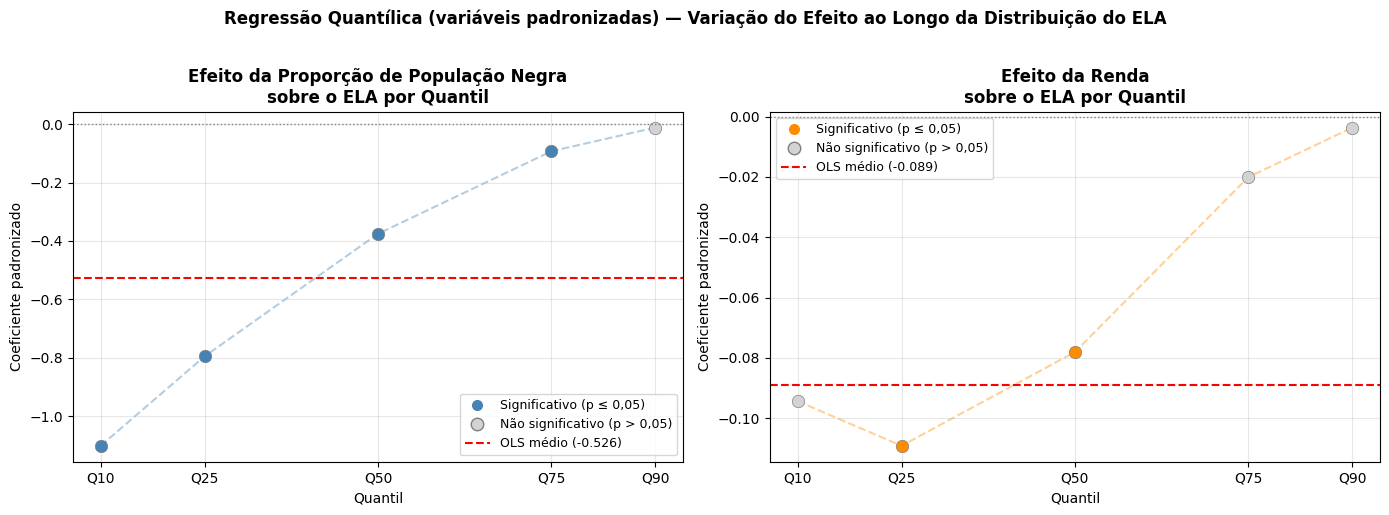

In [20]:
# =============================================================================
# GRÁFICO — Coeficientes NÃO significativos (p > 0.05) aparecem em CINZA
# =============================================================================

coefs_pnegra = [resultados_quantilicos[q].params["pnegra"] for q in quantis]
coefs_renda  = [resultados_quantilicos[q].params["renda"]  for q in quantis]
p_pnegra     = [resultados_quantilicos[q].pvalues["pnegra"] for q in quantis]
p_renda      = [resultados_quantilicos[q].pvalues["renda"]  for q in quantis]

# Define a cor de cada ponto: azul/laranja se significativo, cinza se não
cores_pnegra = ["steelblue" if p <= 0.05 else "lightgray" for p in p_pnegra]
cores_renda  = ["darkorange" if p <= 0.05 else "lightgray" for p in p_renda]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Raça ---
# Plota a linha contínua por baixo (sem cor de ponto)
axes[0].plot(quantis, coefs_pnegra, color="steelblue", linewidth=1.5,
             linestyle="--", alpha=0.4, zorder=1)
# Plota cada ponto individualmente com sua cor
for i, (q, coef, cor) in enumerate(zip(quantis, coefs_pnegra, cores_pnegra)):
    label = None
    if i == 0:  # Adiciona legenda só no primeiro ponto de cada tipo
        label = "Significativo (p ≤ 0,05)" if cor != "lightgray" else "Não significativo (p > 0,05)"
    axes[0].scatter(q, coef, color=cor, s=80, zorder=2,
                    edgecolors="gray", linewidths=0.5)

axes[0].axhline(y=ols_pnegra, color="red", linestyle="--",
                linewidth=1.5, label=f"OLS médio ({ols_pnegra:.3f})")
axes[0].axhline(y=0, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("Efeito da Proporção de População Negra\nsobre o ELA por Quantil",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Quantil")
axes[0].set_ylabel("Coeficiente padronizado")
axes[0].set_xticks(quantis)
axes[0].set_xticklabels([f"Q{int(q*100)}" for q in quantis])

# Legenda manual para explicar as cores
from matplotlib.lines import Line2D
legenda_elementos = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=9, label="Significativo (p ≤ 0,05)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgray",
           markeredgecolor="gray", markersize=9, label="Não significativo (p > 0,05)"),
    Line2D([0], [0], color="red", linestyle="--", linewidth=1.5,
           label=f"OLS médio ({ols_pnegra:.3f})")
]
axes[0].legend(handles=legenda_elementos, fontsize=9)
axes[0].grid(alpha=0.3)

# --- Gráfico 2: Renda ---
axes[1].plot(quantis, coefs_renda, color="darkorange", linewidth=1.5,
             linestyle="--", alpha=0.4, zorder=1)
for q, coef, cor in zip(quantis, coefs_renda, cores_renda):
    axes[1].scatter(q, coef, color=cor, s=80, zorder=2,
                    edgecolors="gray", linewidths=0.5)

axes[1].axhline(y=ols_renda, color="red", linestyle="--",
                linewidth=1.5, label=f"OLS médio ({ols_renda:.3f})")
axes[1].axhline(y=0, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Efeito da Renda\nsobre o ELA por Quantil",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Quantil")
axes[1].set_ylabel("Coeficiente padronizado")
axes[1].set_xticks(quantis)
axes[1].set_xticklabels([f"Q{int(q*100)}" for q in quantis])

legenda_elementos2 = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkorange",
           markersize=9, label="Significativo (p ≤ 0,05)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgray",
           markeredgecolor="gray", markersize=9, label="Não significativo (p > 0,05)"),
    Line2D([0], [0], color="red", linestyle="--", linewidth=1.5,
           label=f"OLS médio ({ols_renda:.3f})")
]
axes[1].legend(handles=legenda_elementos2, fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Regressão Quantílica (variáveis padronizadas) — Variação do Efeito ao Longo da Distribuição do ELA",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()

plt.show()

#Exportar os dados usados

In [21]:
print(df.columns)
novo_df = df[['Cod_setor', 'CIDADE', 'BAIRRO', 'POP V0002', 'DOM V001', 'ÁGUA V012',
       'ESG. V017', 'LIXO V035', 'Residentes', 'branca', 'preta', 'amarela',
       'parda', 'INDÍGENA', 'Renda dom.', 'Sem renda','ELA']].copy()
display(novo_df)
novo_df.to_csv(
    "dados_setores1.csv",
    index=False,
    encoding="utf-8-sig"
)

Index(['Cod_setor', 'CIDADE', 'BAIRRO', 'POP V0002', 'DOM V001', 'ÁGUA V012',
       'ESG. V017', 'LIXO V035', 'Residentes', 'branca', 'preta', 'amarela',
       'parda', 'INDÍGENA', 'Renda dom.', 'Sem renda', 'ÁGUA V012 %',
       'ESG. V017 %', 'LIXO V035 %', 'soma', 'ind.mariana', 'plixo', 'pesg',
       'pagua', 'ELA', 'pbranca', 'ppreta', 'pparda', 'pnegra', 'renda',
       'faixa_pnegra', 'faixa_renda'],
      dtype='object')


,Cod_setor,CIDADE,BAIRRO,POP V0002,DOM V001,ÁGUA V012,ESG. V017,LIXO V035,Residentes,branca,preta,amarela,parda,INDÍGENA,Renda dom.,Sem renda,ELA
0,330330205000197,NITERÓI,Icaraí,736.0,261,261.0,261.0,261.0,736,653.0,15.0,4.0,62.0,2.0,4987177,3,100.000000
1,330330205000640,NITERÓI,Santo Antônio,1269.0,390,371.0,342.0,390.0,1269,1094.0,32.0,5.0,138.0,0.0,4419836,6,94.273504
2,330330205000179,NITERÓI,Icaraí,1022.0,409,409.0,409.0,409.0,1022,895.0,17.0,2.0,108.0,0.0,4246405,8,100.000000
3,330330205000825,NITERÓI,Charitas,773.0,227,226.0,215.0,227.0,773,692.0,19.0,6.0,56.0,0.0,3737228,3,98.091043
4,330330205000595,NITERÓI,Pé Pequeno,1463.0,550,550.0,550.0,550.0,1463,1289.0,33.0,8.0,127.0,6.0,3713809,35,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,330330205000859,NITERÓI,Itacoatiara,24.0,8,7.0,8.0,8.0,24,21.0,3.0,0.0,0.0,0.0,17365,0,95.833333
865,330330205000893,NITERÓI,Tenente Jardim,69.0,14,14.0,3.0,10.0,69,3.0,50.0,0.0,16.0,0.0,17072,0,64.285714
866,330330205000775,NITERÓI,Engenho do Mato,33.0,14,13.0,14.0,14.0,33,22.0,0.0,0.0,11.0,0.0,16862,0,97.619048
867,330330205000789,NITERÓI,Engenho do Mato,29.0,12,4.0,4.0,10.0,29,17.0,0.0,0.0,12.0,0.0,13710,1,50.000000


#Preparar gráfico de setores censitarios

In [22]:
# Nova coluna: identifica se a comunidade é majoritariamente branca
df["grupo_branco"] = df.apply(
    lambda row: "Majoritariamente Branca" if row["pbranca"] > row["pnegra"] else "Demais Comunidades",
    axis=1
)


In [23]:
def classificar_grupo_racial(row):
    if row["pnegra"] > 51:
        return "Maioritariamente Negra"
    elif row["pbranca"] > 51:
        return "Maioritariamente Branca"
    else:
        return "Sem maioria clara"

df["grupo_racial_51"] = df.apply(classificar_grupo_racial, axis=1)

##Grafico renda vs ELA
###Grafico dos setores censitarios na cidade de niteroi

In [24]:
# --- CÁLCULO DA MÉDIA DE ELA POR GRUPO ---

# 1. Agrupamos os dados pela coluna 'grupo_racial_51'
# 2. Selecionamos a coluna 'ELA'
# 3. Calculamos a média (mean)
# 4. .sort_values() ajuda a ver rapidamente qual grupo tem o maior/menor índice
media_ela_grupos = df.groupby("grupo_racial_51")["ELA"].mean().sort_values(ascending=False)

print("Média do Índice ELA por Grupo Racial:")
print(media_ela_grupos)

# DICA PARA O RELATÓRIO:
# Compare se a diferença entre as médias desses 3 grupos é grande.
# Se o grupo com maior proporção negra tiver um ELA significativamente menor,
# você tem mais uma evidência da desigualdade ambiental que discutimos na regressão.

Média do Índice ELA por Grupo Racial:
grupo_racial_51
Maioritariamente Branca    95.999779
Sem maioria clara          89.282703
Maioritariamente Negra     87.298437
Name: ELA, dtype: float64


In [25]:
import plotly.express as px

fig = px.scatter(
    df,
    x="renda",
    y="ELA",
    color="grupo_racial_51",
    hover_name="pnegra",
    labels={
        "renda": "Renda média (R$)",
        "ELA": "Índice E.L.A",
        "grupo_racial_51": "Composição racial"
    },
    title="Relação entre Renda e ELA conforme Composição Racial (>51%)",

    category_orders={
        "grupo_racial_51": [
            "Maioritariamente Branca",
            "Maioritariamente Negra",
            "Sem maioria clara"
        ]
    }
)
fig.add_hline(
    y=87.29,
    line_dash="dot",   # pontilhado
    line_width=2,
    line_color="red",
    annotation_text="Média ELA",
    annotation_font_color="red",   #
    annotation_position="top right",
    opacity=0.8
)
fig.add_hline(
    y=95.99,
    line_dash="dot",   # pontilhado
    line_width=2,
    line_color="blue",
    annotation_text="Média ELA",
    annotation_font_color="blue",   #
    annotation_position="top right",
    opacity=0.8
)
# estilo geral minimalista
fig.update_traces(marker=dict(size=9, opacity=0.75, line=dict(width=0)))

fig.update_layout(
    width=850,
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=13),
    title=dict(font=dict(size=18),
        x=0.5, xanchor="center",
    yanchor="top"),

    legend_title_text="Composição racial",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.3,
        xanchor="left",
        x=0
    )
)

# grelha suave
fig.update_xaxes(showgrid=True, gridwidth=0.6, gridcolor="#ECECEC", zeroline=False)
fig.update_yaxes(showgrid=True, gridwidth=0.6, gridcolor="#ECECEC", zeroline=False)
fig.update_layout(    font=dict(color="black"))


fig.update_layout(

    # 1. Tamanho do Título Principal
    title=dict(
        font=dict(size=22)  # Aumentado para 22 (padrão costuma ser 18)
    ),

    # 2. Tamanho dos Títulos dos Eixos (Labels principais)
    xaxis_title=dict(font=dict(size=20)),
    yaxis_title=dict(font=dict(size=20)),

    # 3. Tamanho dos valores dos eixos (as categorias/números da escala)
    xaxis=dict(tickfont=dict(size=16)),
    yaxis=dict(tickfont=dict(size=16)),

    # 4. Tamanho do texto da Legenda (caso seu gráfico use)
    legend=dict(
        font=dict(size=14),
        title=dict(font=dict(size=15))
    ))


fig.show()


In [26]:
corte = 51
filtro1 = df['pnegra'] > corte
rendamedia = df[filtro1]['renda'].mean()
print(f"Media de renda de setore censitarios negros com corde > {corte} = {rendamedia}" )
filtro1 = df['pbranca']> corte
rendamedia = df[filtro1]['renda'].mean()
print(f"Media de renda de setore censitarios brancos com corde > {corte} = {rendamedia}" )

Media de renda de setore censitarios negros com corde > 51 = 1522.5547812120199
Media de renda de setore censitarios brancos com corde > 51 = 5586.279551957797
